# F_hit_miss.ipynb

## Purpose
Analyzes behavioral and neural factors underlying hit vs. miss responses to the go cue. Fits a logistic regression GLM predicting upcoming hit/miss from reward history across multiple lags, both per-session and per-animal.

## Manuscript figure panels
- Fig5

## Prerequisites
Before running this notebook, ensure the figure preparation scripts have been run in sequence (see `/root/capsule/code/beh_ephys_analysis/session_combine/figure_preparation/sequence`).

Required input files:
- `combined_beh_sessions.pkl` (generated by behavior_metrics_generation.py)

In [1]:
import sys
import os
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb, plot_session_glm
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm
from utils.capsule_migration import capsule_directories
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
from matplotlib import cm
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from utils.combine_tools import apply_qc
capsule_dirs = capsule_directories()
%matplotlib inline
from utils.capsule_migration import CAPSULE_ROOT
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


## Data Loading

Load the combined behavioral sessions dataset that contains trial-by-trial behavioral data across all animals and sessions. This dataset was generated during the figure preparation stage and includes response types, reward history, and choice information for each trial.

In [2]:
beh_combined_file = f'{capsule_dirs["manuscript_fig_prep_dir"]}/combined_session_tbl/combined_beh_sessions.pkl'
with open(beh_combined_file, 'rb') as f:
    beh_combined = pickle.load(f)

## GLM Model Definitions

### Per-Session Hit/Miss Prediction Model

Define a logistic regression model to predict hit vs. miss responses from reward history. The model constructs predictor matrices by lagging reward and hit history across multiple trials, then fits a logistic GLM to predict whether the animal will respond (hit) or not respond (miss) on the current trial. This per-session version allows analysis of individual session behavior patterns.

In [3]:
# regression model, use past rewards/no reward,  to predict future go/no-go
def hit_glm(session):
    session_tbl = get_session_tbl(session)

    t_Max = 3
    t_Max_hist = 0

    hit = session_tbl['animal_response'].values != 2
    rewards = (session_tbl['rewarded_historyL'].values == 1) | (session_tbl['rewarded_historyR'].values == 1)
    rewards[~hit] = np.nan  # only consider rewards when there is a hit
    choice = session_tbl['animal_response'].values
    pre_choice = np.full(len(choice), np.nan)
    pre_choice[1:] = choice[:-1]
    for i in range(1, len(choice)):
        if pre_choice[i] == 2:  # no-go
            last_choice = np.where(choice[:i] != 2)[0][-1] if np.any(choice[:i] != 2) else 0
            pre_choice[i] = choice[last_choice] if last_choice > 0 else np.nan

    # for each pre_choice == 2, get the lastest choice that is not 2


    hit_mtx = np.full((t_Max_hist, len(hit)), np.nan, dtype=float)
    for i in range(t_Max_hist):
        hit_mtx[i, i+1:] = hit[:(len(hit)-(i+1))]

    rwd_mtx = np.full((t_Max, len(hit)), np.nan, dtype=float)
    for i in range(t_Max):
        rwd_mtx[i, i+1:] = rewards[:(len(hit)-(i+1))]
    col_list = [f'rwd_{i+1}' for i in range(t_Max)]
    pre_hist_list = [f'hit_{i+1}' for i in range(t_Max_hist)]
    col_list.extend(pre_hist_list)
    matrix = np.concatenate((rwd_mtx, hit_mtx), axis=0)
    reg_df = pd.DataFrame(matrix.T, columns=col_list)
    reg_df['hit'] = hit
    # reg_df['pre_choice'] = pre_choice
    # use statsmodels to fit a GLM
    X = reg_df.drop(columns=['hit']).values
    y = reg_df['hit'].values
    X = sm.add_constant(X)  # add intercept term
    # nan mask to filter nan mask
    nan_mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[nan_mask]
    y = y[nan_mask]
    model = sm.Logit(y, X)
    result = model.fit()
    # print(result.summary())

    rwd_coeffs = result.params[1:t_Max+1]
    hit_coeffs = result.params[t_Max+1:-1]
    # pre_choice_coeff = result.params[-1]

    # # plot coefficients
    # plt.figure(figsize=(10, 6))
    # plt.bar(range(t_Max), rwd_coeffs, label='Reward Coefficients', alpha=0.7)
    # plt.bar(range(t_Max, t_Max + t_Max_hist + 1), hit_coeffs, label='Hit Coefficients', alpha=0.7)
    # plt.bar(range(t_Max + t_Max_hist + 1, t_Max + t_Max_hist+2), pre_choice_coeff, label='Hit Coefficients', alpha=0.7)
    # plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    # plt.xlabel('Time Lag')
    # plt.ylabel('Coefficient Value')
    # plt.title('GLM Coefficients for Reward and Hit History')
    return {'rwd_coeffs': rwd_coeffs,
            'hit_coeffs': hit_coeffs,
            # 'pre_choice_coeff': pre_choice_coeff,
            'session_id': session}



### Per-Animal Hit/Miss Prediction Model

Extend the GLM approach to aggregate all sessions from a single animal. This per-animal model pools trials across sessions to estimate animal-level reward history effects on hit/miss behavior. By combining data across sessions, this approach captures stable behavioral strategies that persist across recording days while accounting for individual differences between animals.

In [4]:
# regression model, use past rewards/no reward,  to predict future go/no-go
def hit_glm_ani(ani, t_Max = 3, t_Max_hist = 0):

    session_list_file = f'{capsule_dirs["manuscript_fig_prep_dir"]}/combined_session_tbl/combined_beh_sessions.pkl'
    with open(session_list_file, 'rb') as f:
        combined_session_tbl = pickle.load(f)
    session_list = combined_session_tbl[combined_session_tbl['ani_id'] == ani]['session_id'].values
    combined_reg_df = pd.DataFrame()
    for session in session_list:
        session_tbl = get_session_tbl(session)

        hit = session_tbl['animal_response'].values != 2
        rewards = (session_tbl['rewarded_historyL'].values == 1) | (session_tbl['rewarded_historyR'].values == 1)
        # rewards[~hit] = np.nan  # only consider rewards when there is a hit
        choice = session_tbl['animal_response'].values
        pre_choice = np.full(len(choice), np.nan)
        pre_choice[1:] = choice[:-1]
        for i in range(1, len(choice)):
            if pre_choice[i] == 2:  # no-go
                last_choice = np.where(choice[:i] != 2)[0][-1] if np.any(choice[:i] != 2) else 0
                pre_choice[i] = choice[last_choice] if last_choice > 0 else np.nan

        hit_mtx = np.full((t_Max_hist, len(hit)), np.nan, dtype=float)
        for i in range(t_Max_hist):
            hit_mtx[i, i+1:] = hit[:(len(hit)-(i+1))]

        rwd_mtx = np.full((t_Max, len(hit)), np.nan, dtype=float)
        for i in range(t_Max):
            rwd_mtx[i, i+1:] = rewards[:(len(hit)-(i+1))]
        # create a DataFrame for regression
        col_list = [f'rwd_{i+1}' for i in range(t_Max)]
        pre_hist_list = [f'hit_{i+1}' for i in range(t_Max_hist)]
        col_list.extend(pre_hist_list)
        matrix = np.concatenate((rwd_mtx, hit_mtx), axis=0)
        reg_df = pd.DataFrame(matrix.T, columns=col_list)
        reg_df['hit'] = hit
        # reg_df['pre_choice'] = pre_choice
        # use statsmodels to fit a GLM
        # nan_df = df.DataFrame(np.full((len(reg_df), len(reg_df.columns)), np.nan), columns=reg_df.columns)
        combined_reg_df = pd.concat([combined_reg_df, reg_df], ignore_index=True)

    X = combined_reg_df.drop(columns=['hit']).values
    y = combined_reg_df['hit'].values
    X = sm.add_constant(X)  # add intercept term
    # nan mask to filter nan mask
    nan_mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[nan_mask]
    y = y[nan_mask]
    model = sm.Logit(y, X)
    result = model.fit()
    # print(result.summary())

    rwd_coeffs = result.params[1:t_Max+1]
    hit_coeffs = result.params[t_Max+1:-1]
    # pre_choice_coeff = result.params[-1]
    rwd_CI = result.conf_int()[1:t_Max+1]
    hit_CI = result.conf_int()[t_Max+1:-1]

    # # plot coefficients
    # plt.figure(figsize=(10, 6))
    # plt.bar(range(t_Max), rwd_coeffs, label='Reward Coefficients', alpha=0.7)
    # plt.bar(range(t_Max, t_Max + t_Max_hist + 1), hit_coeffs, label='Hit Coefficients', alpha=0.7)
    # plt.bar(range(t_Max + t_Max_hist + 1, t_Max + t_Max_hist+2), pre_choice_coeff, label='Hit Coefficients', alpha=0.7)
    # plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    # plt.xlabel('Time Lag')
    # plt.ylabel('Coefficient Value')
    # plt.title('GLM Coefficients for Reward and Hit History')
    return {'rwd_coeffs': rwd_coeffs,
            'hit_coeffs': hit_coeffs,
            'rwd_CI': rwd_CI,
            'hit_CI': hit_CI,
            # 'pre_choice_coeff': pre_choice_coeff,
            'ani_id': ani}



## Per-Animal GLM Analysis

Fit the per-animal GLM model across all animals in parallel to examine individual differences in how reward history influences hit/miss behavior. This analysis reveals whether the effect of past rewards on current trial engagement is consistent across animals or shows substantial individual variability. The parallel processing framework enables efficient computation across the full dataset.

### Visualize Per-Animal Reward History Coefficients

Plot the reward history coefficients for each animal to visualize individual differences. Each line represents one animal's sensitivity to reward history at different trial lags, showing how the influence of past rewards decays over time and varies across individuals.

## Population-Level GLM Model

### All-Trials Model Definition

Define a population-level logistic regression model that pools trials from all sessions and all animals. This approach provides the most statistically powerful estimate of how reward history influences hit/miss behavior at the population level, revealing general principles that transcend individual and session-specific variability. The model uses parallel processing to efficiently construct the design matrix from the full dataset.

In [5]:
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import pickle
import statsmodels.api as sm


def _build_hit_glm_session_df(session, t_Max, t_Max_hist):
    session_tbl = get_session_tbl(session)

    hit = session_tbl['animal_response'].values != 2
    rewards = (
        (session_tbl['rewarded_historyL'].values == 1) |
        (session_tbl['rewarded_historyR'].values == 1)
    )

    choice = session_tbl['animal_response'].values
    # pre_choice = np.full(len(choice), np.nan)
    # pre_choice[1:] = choice[:-1]

    # for i in range(1, len(choice)):
    #     if pre_choice[i] == 2:  # no-go
    #         last_choice_inds = np.where(choice[:i] != 2)[0]
    #         last_choice = last_choice_inds[-1] if len(last_choice_inds) > 0 else -1
    #         pre_choice[i] = choice[last_choice] if last_choice >= 0 else np.nan

    hit_mtx = np.full((t_Max_hist, len(hit)), np.nan, dtype=float)
    for i in range(t_Max_hist):
        hit_mtx[i, i + 1:] = hit[:len(hit) - (i + 1)]

    rwd_mtx = np.full((t_Max, len(hit)), np.nan, dtype=float)
    for i in range(t_Max):
        rwd_mtx[i, i + 1:] = rewards[:len(hit) - (i + 1)]

    col_list = [f'rwd_{i+1}' for i in range(t_Max)]
    pre_hist_list = [f'hit_{i+1}' for i in range(t_Max_hist)]
    col_list.extend(pre_hist_list)

    matrix = np.concatenate((rwd_mtx, hit_mtx), axis=0)
    reg_df = pd.DataFrame(matrix.T, columns=col_list)
    reg_df['hit'] = hit
    # reg_df['pre_choice'] = pre_choice

    return reg_df


# regression model, use past rewards/no reward, to predict future go/no-go
def hit_glm_all_trial(t_Max, t_Max_hist=0, n_jobs=-1, backend='loky', verbose=10):
    session_list_file = str(capsule_directories()['manuscript_fig_prep_dir']) + '/combined_session_tbl/combined_beh_sessions.pkl'
    with open(session_list_file, 'rb') as f:
        combined_session_tbl = pickle.load(f)

    session_list = combined_session_tbl['session_id'].values

    reg_df_list = Parallel(n_jobs=n_jobs, backend=backend, verbose=verbose)(
        delayed(_build_hit_glm_session_df)(session, t_Max, t_Max_hist)
        for session in session_list
    )

    combined_reg_df = pd.concat(reg_df_list, ignore_index=True)

    X = combined_reg_df.drop(columns=['hit']).values
    y = combined_reg_df['hit'].values.astype(float)

    X = sm.add_constant(X)

    nan_mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[nan_mask]
    y = y[nan_mask]

    model = sm.Logit(y, X)
    result = model.fit()

    rwd_coeffs = result.params[1:t_Max + 1]
    hit_coeffs = result.params[t_Max + 1:t_Max + 1 + t_Max_hist]

    rwd_CI = result.conf_int()[1:t_Max + 1]
    hit_CI = result.conf_int()[t_Max + 1:t_Max + 1 + t_Max_hist]

    return {
        'rwd_coeffs': rwd_coeffs,
        'hit_coeffs': hit_coeffs,
        'rwd_CI': rwd_CI,
        'hit_CI': hit_CI,
        'model': result,
        'combined_reg_df': combined_reg_df,
    }

## Fit Population-Level Model

Fit the logistic regression model using all trials from all sessions to estimate population-level reward history effects. The model examines reward history up to 15 trials back to characterize the temporal decay of reward influence on behavioral engagement. This analysis provides the primary result showing how past reward outcomes shape future task engagement.

In [6]:
tMax = 15
tMax_hist = 0
result = hit_glm_all_trial(tMax, tMax_hist);

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   11.9s


[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   17.0s


[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   24.3s


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   31.4s


...

[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:  1.8min


[Parallel(n_jobs=-1)]: Done 281 tasks      | elapsed:  1.9min


[Parallel(n_jobs=-1)]: Done 306 tasks      | elapsed:  2.1min


[Parallel(n_jobs=-1)]: Done 345 out of 345 | elapsed:  2.3min finished


Optimization terminated successfully.
         Current function value: 0.177641
         Iterations 8


## Manuscript Figure Generation

Generate the final publication-quality figure showing population-level reward history coefficients with confidence intervals. The left panel displays how reward history at different trial lags influences the probability of a hit response, with error bars representing 95% confidence intervals. This figure demonstrates the temporal dynamics of reward-driven behavioral engagement and will be included as Fig5 in the manuscript.

['/root/capsule/scratch/results/manuscript/figures/F_hit_miss/Figure5a_GLM_hit_reward_coefficients.csv']

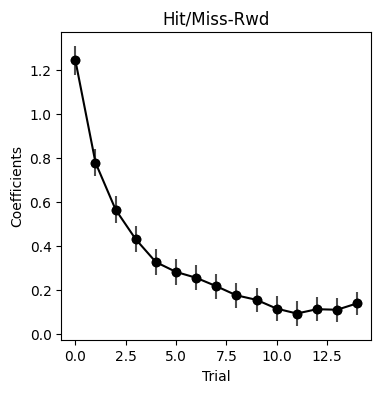

In [7]:
# plot results
rwd_coeffs = result['rwd_coeffs']
rwd_CI = result['rwd_CI']
hit_coeffs = result['hit_coeffs']
hit_CI = result['hit_CI']
fig, ax = plt.subplots(1, 1, figsize =(4, 4))
ax.plot(range(tMax), rwd_coeffs, 'k', marker='o', label='Reward Coefficients')
ax.errorbar(range(tMax), rwd_coeffs, yerr=[rwd_coeffs - rwd_CI[:, 0], rwd_CI[:, 1] - rwd_coeffs], fmt='o', alpha=0.7, c = 'k')
ax.set_xlabel('Trial')
ax.set_title('Hit/Miss-Rwd')
ax.set_ylabel('Coefficients')
# ax = axes[1]
# ax.plot(range(tMax_hist), hit_coeffs, 'k', marker='o', label='History Coefficients', )
# ax.errorbar(range(tMax_hist), hit_coeffs, yerr=[hit_coeffs - hit_CI[:, 0], hit_CI[:, 1] - hit_coeffs], fmt='o', alpha=0.7, c = 'k')
# ax.set_title('Hist')
save_dir = os.path.join(capsule_dirs["manuscript_fig_dir"], 'F_hit_miss')
os.makedirs(save_dir, exist_ok=True)
save_panels(fig, save_dir, 'GLM_hit_reward_coefficients', ['Figure5a'], exts=('pdf',), bbox_inches='tight')
# ---- panel CSV (rule 5: 1D errorbar, reward & history GLM coeffs with CI) ----
save_panel_csv(columns_to_df(reward_trial=np.arange(tMax), reward_coeff=rwd_coeffs, reward_ci_low=rwd_CI[:, 0], reward_ci_high=rwd_CI[:, 1], hist_trial=np.arange(tMax_hist), hist_coeff=hit_coeffs, hist_ci_low=hit_CI[:, 0], hist_ci_high=hit_CI[:, 1]), save_dir, 'GLM_hit_reward_coefficients', ['Figure5a'])
##Figure5a##